In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import mode_analysis_code_original_repo as ma
import multiprocessing

In [6]:
#Specify parameters for file reading
num_files = 1          #number of files to read
times_rec = 101        #number of recorded timesteps
num_particles = 100    #number of ions
duration = 1.0         #simulation duration in ms
Omega1 = 33.9          #Rabi frequency beam 1 (MHz)
Omega2 = 33.9          #Rabi frequency beam 2 (MHz)

In [7]:
data_par = np.array([])

#read_output() reads and returns internal-state density matrix of each ion at each recorded timestep
#returned array has shape (num_files, times_rec, 9, num_particles), where the middle index is the density matrix element

def read_output(file_num, ret_params=False): 
    f = open("output/int_state_output_EIT_100i_3D_092926_0.txt", "rb")  #change to name of your output file 
    #if num_files > 1, the command may look something like
    #f = open("output_data/int_state_output_EIT_100i_092926_" +str(file_num) + ".txt", "rb") 

    print("file: " + str(file_num))

    time_counter = 0 
    type_counter = 0  
    val_counter = 0  

    data = np.zeros((times_rec,9,num_particles),dtype=np.complex128)

    while time_counter < times_rec:
        #read data for this timestep
        type_array = np.zeros((9, num_particles),dtype=np.complex128)  
        while val_counter < num_particles:
            val_array = np.array([],dtype=np.complex128) 
            while type_counter < 9:
                f.seek(1,1) #skip parentheses
                data_byte = f.read(12)
                if float(data_byte) >= 0 and str(float(data_byte))[0] != '-': 
                    f.seek(-12,1)
                    data_byte = f.read(12)
                else:
                    f.seek(-12,1)
                    data_byte = f.read(13)

                f.seek(1,1) #skip comma
                data_byte2 = f.read(12)
                
                if float(data_byte2) >= 0 and str(float(data_byte2))[0] != '-': #second coniditon is for -0.0e00
                    #print(str(float(data_byte)))
                    f.seek(-12,1)
                    data_byte2 = f.read(12)

                else:
                    f.seek(-12,1)
                    data_byte2 = f.read(13)

                this_val = complex(float(data_byte), float(data_byte2))
                val_array = np.append(val_array, this_val)

                f.seek(2,1) #skip paren and space
                type_counter+=1

            type_array[:,val_counter] = val_array
            type_counter = 0
            val_counter+=1
        data[time_counter] = type_array
        val_counter=0
        time_counter+=1

    return data

params = []
for i in range(num_files):
    params.append([i])

with multiprocessing.Pool(processes=20) as pool:
    data_par = pool.starmap(read_output, params)
    
data_par = np.array(data_par)



file: 0


In [8]:
print(data_par.shape)

(1, 101, 9, 100)


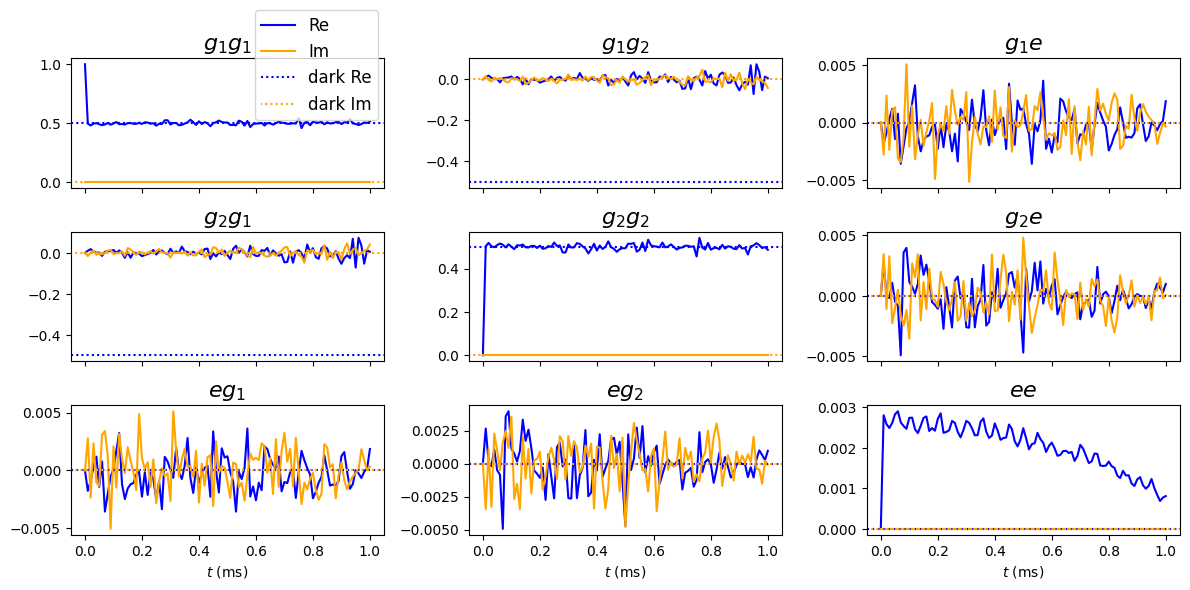

In [9]:
D = np.array([Omega2, -Omega1, 0], dtype=complex)
D = D / np.linalg.norm(D)
rho_dark = np.outer(D, D.conj())

rho_mats = np.array([np.mean(np.mean(data_par[:,n,:,:], axis = 0),axis=1).reshape((3,3), order="F") for n in range(times_rec)])

labels = [r"$g_1g_1$", r"$g_1g_2$", r"$g_1e$",
          r"$g_2g_1$", r"$g_2g_2$", r"$g_2e$",
          r"$eg_1$", r"$eg_2$", r"$ee$"]
t=np.linspace(0,duration,times_rec)

fig, axes = plt.subplots(3, 3, figsize=(12, 6), sharex=True)

for i in range(3):
    for j in range(3):
        ax = axes[i, j]

        ax.plot(t[::1], rho_mats[:, i, j].real[::1],color="blue",label="Re")
        ax.plot(t[::1], rho_mats[:, i, j].imag[::1],color="orange",label="Im")

        ax.axhline(rho_dark[i, j].real, color="blue", linestyle=(0, (1, 1.5)),label="dark Re")
        ax.axhline(rho_dark[i, j].imag, color="orange", linestyle=(3, (1, 1.5)), label="dark Im")

        ax.set_title(labels[3*i + j], fontsize=16)

        if(i==0 and j==0):
            ax.legend(loc="center left", bbox_to_anchor=(0.56, 0.95), fontsize = 12)

axes[-1, 0].set_xlabel(r"$t$ (ms)")
axes[-1, 1].set_xlabel(r"$t$ (ms)")
axes[-1, 2].set_xlabel(r"$t$ (ms)")

plt.tight_layout()